# Self-Filling Gas Station Price Analysis

## 1. 주유소 정보를 웹크롤링을 통해 수집해서 그 정보를 담은 Pandas DataFrame 만들기

### 일단, 웹사이트에서 데이터를 가져오려고 selenium과 beautifulsoup 필요해서 설치 및 import하겠습니다
- conda install selenium
- conda install bs4
- chromedriver - Chrome 버전 확인하고(chrome://settings/help) Google에서 "chrome 드라이버 다운로드"를 검색해서 버전의 첫 번째 부분과 일치하는 chromedriver를 가져오겠습니다. (https://developer.chrome.com/docs/chromedriver/downloads)
- 최저 유가 웹사이트: https://www.opinet.co.kr/searRgSelect.do - 여기서 엑셀으로 저장할 수도 있지만 스스로 도전하려고 그 엑셀 저장 피처를 사용하지 않고 웹 크롤링으로 데이터 수집해보겠습니다.

### 데이터 확보하기 위한 작업
- 개발자 도구를 사용해서 사이트 구조 확인
- 목표 데이터 (총 14 컬럼) - 컬럼 이름 영문으로 아래 양식대로 저장하겠습니다
    - 주유소명: Station
    - 주소: Address
    - 브랜드: Brand
    - 휘발유 가격: Gas Price
    - 경유 가격: Diesel Price
    - 셀프 여부: Self
    - 세차장 여부: Carwash
    - 충전소 여부: LPG Charging
    - 경정비 여부: Maintenance
    - 편의점 여부: Convenience Store
    - 24시간 운영 여부: 24 Hours
    - 구: District
    - 위도: Latitude
    - 경도: Longitude

### selenium으로 접근

In [5]:
from selenium import webdriver

In [6]:
# 페이지 접근
url = "https://www.opinet.co.kr/searRgSelect.do"
c_service = webdriver.ChromeService()
driver = webdriver.Chrome(service=c_service)
# driver = webdriver.Chrome("../drive/chromedriver.exe")
driver.get(url)

In [7]:
# 지역: 시 / 도 선택 목록 구하기
# drop-down menu는 "SIDO_NM0"이라는 ID있고
# 각 지역 선택은 "option"이라는 태그 안에 있다
from selenium.webdriver.common.by import By
sido_list_raw = driver.find_element(By.ID, 'SIDO_NM0')
sido_list = sido_list_raw.find_elements(By.TAG_NAME, 'option')

# 각 태그 안에 있는 "value"로 리스트 만들고 ''값 제거하기
sido_names = [option.get_attribute("value") for option in sido_list]
sido_names = sido_names[1:]

# 서울특별시 선택하기
sido_list_raw.send_keys(sido_names[0])

In [8]:
# 구 선택 목록 구하기
# drop-down menu는 "SIGUNGU_NM0"이라는 ID있고
# 각 구 선택은 "option"이라는 태그 안에 있다
# 각 태그 안에 있는 "value"로 리스트 만들고 ''값 제거하기
gu_list_raw = driver.find_element(By.ID, 'SIGUNGU_NM0')
gu_list = gu_list_raw.find_elements(By.TAG_NAME, 'option')
gu_names = [option.get_attribute("value") for option in gu_list]
gu_names = gu_names[1:]

# 테스트로 동대문구 선택하기
gu_list_raw.send_keys(gu_names[10])

In [9]:
# 조회 버튼 클릭하기
driver.find_element(By.CSS_SELECTOR, '#searRgSelect').click()

### 엑셀 저장하지 않고 웹크롤링으로만 데이터 수집 하려면 그 데이터 소스 코드에는 어디에 있는지 확인 해야 합니다
- 개발자 도구를 사용해서 사이트 구조 확인한다.
- 구별 검색 결과가 "body1"이라는 ID인 "tbody"태그 안에 있다 (CSS_SELECTOR = "#body1")
- 각 주유소 이름을 클릭하면 더 자세한 정보가 있는 pop-up 윈도우가 나타난다.
- selenium으로 그 클릭하기 전과 후의 웹페이지 소스를 저장해서 beautifulsoup으로 목표 데이터를 찾아서 수집해야 한다.
- 목표 데이터 (총 14 컬럼) 페이지 안에 위치 - 각 검색 결과가 "tr" 태그 안에 있고, 그 안에서 각 "rlist"이라는 ID인 "td" 태그 안에 > "a" 태그를 클릭한 후 나타나는 pop-up 윈도우 안에 있는 소스 코드를 보면 각 데이터의 위치는 아래와 같다
    - Station Name: label ID="os_nm"
    - Address: label ID="rd_addr"
    - Brand: label ID="poll_div_nm"
    - Gas Price: label ID="b027_p"
    - Diesel Price: label ID="d047_p"
    - Self: span ID="SPAN_SELF_VLT_YN_ID" 안에 "img" 태그 있는 경우 'Y' 아니면 'N'
    - Carwash: img ID="cwsh_yn" 의 "src"attribute 안에 "off"있는 경우 'N' 아니면 'Y'
    - LPG Charging: img ID="lpg_yn" 의 "src"attribute 안에 "off"있는 경우 'N' 아니면 'Y'
    - Maintenance: img ID="maint_yn" 의 "src"attribute 안에 "off"있는 경우 'N' 아니면 'Y'
    - Convenience Store: img ID="cvs_yn" 의 "src"attribute 안에 "off"있는 경우 'N' 아니면 'Y'
    - 24 Hours: img ID="self24_yn" 의 "src"attribute 안에 "off"있는 경우 'N' 아니면 'Y'
    - District: 주유소의 주소의 두 번째 단어
    - Latitude: 나중에 GoogleMaps API를 이용해서 수집 가능
    - Longitude: 나중에 GoogleMaps API를 이용해서 수집 가능

In [10]:
from bs4 import BeautifulSoup

# beautifulsoup으로 클릭하기 전의 소스 저장하기
req = driver.page_source
soup = BeautifulSoup(req, 'html.parser')

# 테스트하기 위해 척 주유소 이름을 클릭하기
driver.find_element(By.CSS_SELECTOR, '#body1 > tr:nth-child(1) > td.rlist > a').click()

# 클릭한 후 beautifulsoup으로 소스 저장하기
req_clicked = driver.page_source
soup_clicked = BeautifulSoup(req_clicked, 'html.parser')

# 선택한 첫 주유소의 정보 확인하기
station_info = soup_clicked.select('#body1 > tr:nth-child(1) > td.rlist > a')
station_info

[<a href="javascript:fn_osPop('','1860','1649','1549','99999','','2026-02-28 15:00:30','2026-02-28 15:01:48','2026-02-28 15:00:52',' ','','317607.00000','552712.00000','* 유가보조금 지정 주유소&lt;br/&gt;','','　','','　',' ','Y','N','HDO','(주)자연에너지 국민주유소','HD현대오일뱅크','02-2216-7155','서울 동대문구 답십리로 223 (답십리동)','N','N','N','','N','A0009232','8698501759','N','N','Y');">
 																
 																															
 																
 																	(주)자연에너지 ...
 																	
 																</a>]

In [11]:
print(soup_clicked.prettify())

<html lang="ko">
 <head>
  <title>
   싼 주유소 찾기 오피넷
  </title>
  <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <meta content="initial-scale=1.0,user-scalable=no" name="viewport"/>
  <link href="/css/user/gis.css?20250704" media="screen" rel="stylesheet" type="text/css"/>
  <script src="/js/user/jquery-1.11.1.min.js" type="text/javascript">
  </script>
  <script src="/js/user/OpinetUIGis.js" type="text/javascript">
  </script>
  <script src="/js/netfunnel.js" type="text/javascript">
  </script>
  <script src="https://nfl.opinet.co.kr:443/ts.wseq?opcode=5004&amp;key=2293C87AEDB3E3459B34E747CF49F76B03774D279CF5212F74837B88BA759E870D8B96CC20CBAC20DAC2D53F6E31B4B6DD4A4FC2CA15B2D27042A948E304E74457471C5AA2C47921DE6F95A6CDBA59CB69F0BB5C96E3BDAB84936679C8DFCA2B6FB4EACC788B5BE49044069E4519500430&amp;nfid=0&amp;prefix=NetFunnel.gRtype=5004;&amp;js=yes&amp;1772277905799">
  </script>
  <script src="/js/user/OpinetUIC

In [12]:
# 주유소 이름, 주소, 브랜드, 휘발유 가격, 경유 가격 구하기
station_name = soup_clicked.find("label", id = 'os_nm').text
address = soup_clicked.find("label", id = 'rd_addr').text
brand = soup_clicked.find("label", id = 'poll_div_nm').text
gas_price = soup_clicked.find("label", id='b027_p').text
diesel_price = soup_clicked.find("label", id='d047_p').text

# 셀프 여부: span ID="SPAN_SELF_VLT_YN_ID" 안에 "img" 태그 있는 경우 'Y' 아니면 'N'
if soup_clicked.find("span", id='SPAN_SELF_VLT_YN_ID').find("img"):
    self = 'Y'
else:
    self = 'N'

# 부가정보 (세차장, 충전소, 경정비, 편의점, 24시간 운영 여부) 다 "img"의 "src"태그 안에 "off"있는 경우 'N' 아니면 'Y'
# 세차장 여부
if "off" in soup_clicked.find("img", id = 'cwsh_yn').attrs['src']:
    carwash = 'N'
else:
    carwash = 'Y'

# 충전소 여부
if "off" in soup_clicked.find("img", id = 'lpg_yn').attrs['src']:
    lpg_charging = 'N'
else:
    lpg_charging = 'Y'

# 경정비 여부
if "off" in soup_clicked.find("img", id = 'maint_yn').attrs['src']:
    maintenance = 'N'
else:
    maintenance = 'Y'

# 편의점 여부
if "off" in soup_clicked.find("img", id = 'cvs_yn').attrs['src']:
    convenience_store = 'N'
else:
    convenience_store = 'Y'

# 24시간 운영 여부
if "off" in soup_clicked.find("img", id = 'sel24_yn').attrs['src']:
    hours24 = 'N'
else:
    hours24 = 'Y'

# 구 이름 구하기: 주유소의 주소의 두 번째 단어
district = address.split()[1]

In [13]:
# 가져온 데이터 확인하기
station_name, address, brand, gas_price, diesel_price, self, carwash, lpg_charging, maintenance, convenience_store, hours24, district

('(주)자연에너지 국민주유소',
 '서울 동대문구 답십리로 223 (답십리동)',
 'HD현대오일뱅크',
 '1,649',
 '1,549',
 'Y',
 'N',
 'N',
 'N',
 'N',
 'N',
 '동대문구')

### 중첩 반복문을 이용해서 각 구 선택한 후 각 주유소를 클릭해서 주유소 데이터 수집하기

In [14]:
import time
from tqdm.notebook import tqdm

stations_info = []

for gu in tqdm(gu_names):
    # 구 선택
    gu_list_raw = driver.find_element(By.ID, 'SIGUNGU_NM0')
    gu_list_raw.send_keys(gu)
    time.sleep(1)
    
    # 조회 버튼 클릭
    driver.find_element(By.CSS_SELECTOR, '#searRgSelect').click()
    time.sleep(1)

    # 주유소 반복문 만들기 위해 구별 주유소 총 개수 구하기 (span class="tc_spot" id="totCnt"의 text)
    total_stations_cnt = int(driver.find_element(By.CSS_SELECTOR, '#totCnt').text)

    # 반복문으로 각 주유소 이름을 클릭해서 데이터 수집하기
    for n in range(1, total_stations_cnt + 1):
        
        # 주유소 이름을 클릭하기
        driver.find_element(By.CSS_SELECTOR, f'#body1 > tr:nth-child({n}) > td.rlist > a').click()
        time.sleep(1)
        
        # 클릭한 후 beautifulsoup으로 소스 저장하기
        req_clicked = driver.page_source
        soup_clicked = BeautifulSoup(req_clicked, 'html.parser')

        # 주유소 이름, 주소, 브랜드, 휘발유 가격, 경유 가격 구하기
        station_name = soup_clicked.find("label", id = 'os_nm').text
        address = soup_clicked.find("label", id = 'rd_addr').text
        brand = soup_clicked.find("label", id = 'poll_div_nm').text
        gas_price = soup_clicked.find("label", id='b027_p').text
        diesel_price = soup_clicked.find("label", id='d047_p').text
        
        # 셀프 여부: span ID="SPAN_SELF_VLT_YN_ID" 안에 "img" 태그 있는 경우 'Y' 아니면 'N'
        if soup_clicked.find("span", id='SPAN_SELF_VLT_YN_ID').find("img"):
            self = 'Y'
        else:
            self = 'N'
        
        # 부가정보 (세차장, 충전소, 경정비, 편의점, 24시간 운영 여부) 다 "img"의 "src"태그 안에 "off"있는 경우 'N' 아니면 'Y'
        # 세차장 여부
        if "off" in soup_clicked.find("img", id = 'cwsh_yn').attrs['src']:
            carwash = 'N'
        else:
            carwash = 'Y'
        
        # 충전소 여부
        if "off" in soup_clicked.find("img", id = 'lpg_yn').attrs['src']:
            lpg_charging = 'N'
        else:
            lpg_charging = 'Y'
        
        # 경정비 여부
        if "off" in soup_clicked.find("img", id = 'maint_yn').attrs['src']:
            maintenance = 'N'
        else:
            maintenance = 'Y'
        
        # 편의점 여부
        if "off" in soup_clicked.find("img", id = 'cvs_yn').attrs['src']:
            convenience_store = 'N'
        else:
            convenience_store = 'Y'
        
        # 24시간 운영 여부
        if "off" in soup_clicked.find("img", id = 'sel24_yn').attrs['src']:
            hours24 = 'N'
        else:
            hours24 = 'Y'
        
        # 구 이름 구하기: 주유소의 주소의 두 번째 단어
        district = address.split()[1]

        station_info = {
            "Station Name": station_name,
            "Address": address, 
            "Brand": brand, 
            "Gas Price": gas_price, 
            "Diesel Price": diesel_price, 
            "Self": self, 
            "Carwash": carwash, 
            "LPG Charging": lpg_charging, 
            "Maintenance": maintenance, 
            "Convenience Store": convenience_store, 
            "24 Hours": hours24, 
            "District": district
        }
        stations_info.append(station_info)

  0%|          | 0/25 [00:00<?, ?it/s]

### pandas으로 DataFrame 만들기

In [21]:
# pandas DataFrame 만들어서 확인하기
import pandas as pd
stations = pd.DataFrame(stations_info)
stations.tail()

,Station Name,Address,Brand,Gas Price,Diesel Price,Self,Carwash,LPG Charging,Maintenance,Convenience Store,24 Hours,District
404,(주)태영 구도일주유소 한인,서울 중랑구 망우로 170,S-OIL,"1,697","1,597",Y,Y,N,Y,N,N,중랑구
405,신내주유소,서울 중랑구 용마산로 705 (신내동),SK에너지,"1,708","1,619",Y,Y,N,N,N,N,중랑구
406,용마로주유소,서울 중랑구 용마산로 309 (면목동),SK에너지,"1,758","1,678",Y,Y,N,N,N,N,중랑구
407,범아주유소,서울 중랑구 동일로 881,S-OIL,"1,769","1,679",N,Y,N,Y,N,N,중랑구
408,신일셀프주유소,서울 중랑구 상봉로 58 (망우동),SK에너지,"1,798","1,698",Y,Y,N,Y,N,Y,중랑구


In [16]:
# DataFrame에 있는 구 값의 개수는 구별 선택 옵션의 개수와 같은지 확인하기 (모든 데이터 수집했는지 확인)
print(len(gu_names), len(stations["District"].unique()))
print(stations["District"].unique())

25 25
['강남구' '강동구' '강북구' '강서구' '관악구' '광진구' '구로구' '금천구' '노원구' '도봉구' '동대문구' '동작구'
 '마포구' '서대문구' '서초구' '성동구' '성북구' '송파구' '양천구' '영등포구' '용산구' '은평구' '종로구' '중구'
 '중랑구']


### NaN 값과 빈값 확인해서 정리하기

In [17]:
# NaN 값 컬컴별 개수 (0인 경우 NaN 값이 없다)
stations.isnull().sum()

Station Name         0
Address              0
Brand                0
Gas Price            0
Diesel Price         0
Self                 0
Carwash              0
LPG Charging         0
Maintenance          0
Convenience Store    0
24 Hours             0
District             0
dtype: int64

In [18]:
# '' 개수 (0인 경우 '' 값이 없다)
(stations == '').sum()

Station Name         0
Address              0
Brand                0
Gas Price            0
Diesel Price         0
Self                 0
Carwash              0
LPG Charging         0
Maintenance          0
Convenience Store    0
24 Hours             0
District             0
dtype: int64

In [19]:
# 경유 가격 컬럼에 '' 값의 행을 확인하기
stations[stations["Diesel Price"] == '']

,Station Name,Address,Brand,Gas Price,Diesel Price,Self,Carwash,LPG Charging,Maintenance,Convenience Store,24 Hours,District


In [22]:
# 총 409개 주유소 중 어떤 컬럼이라도 ''값이 없지만 있었으면 다음과 같이 제거해도 된다
stations = stations[stations["Diesel Price"] != '']
stations.reset_index(inplace=True, drop=True)
stations.tail()

,Station Name,Address,Brand,Gas Price,Diesel Price,Self,Carwash,LPG Charging,Maintenance,Convenience Store,24 Hours,District
404,(주)태영 구도일주유소 한인,서울 중랑구 망우로 170,S-OIL,"1,697","1,597",Y,Y,N,Y,N,N,중랑구
405,신내주유소,서울 중랑구 용마산로 705 (신내동),SK에너지,"1,708","1,619",Y,Y,N,N,N,N,중랑구
406,용마로주유소,서울 중랑구 용마산로 309 (면목동),SK에너지,"1,758","1,678",Y,Y,N,N,N,N,중랑구
407,범아주유소,서울 중랑구 동일로 881,S-OIL,"1,769","1,679",N,Y,N,Y,N,N,중랑구
408,신일셀프주유소,서울 중랑구 상봉로 58 (망우동),SK에너지,"1,798","1,698",Y,Y,N,Y,N,Y,중랑구


In [23]:
# selenium 윈도우 닫기
driver.quit()

### Google Maps API 사용해서 주유소마다 위도, 경도 데이터 가져오기

In [ ]:
import googlemaps
import numpy as np
# 보안을 위해 실제 API 키는 삭제되었습니다. 실행 시 본인의 키를 입력하세요.
# 본인의 Google Maps API Key를 아래 변수에 입력하세요.
gmaps_key = "YOUR_API_KEY_HERE"
gmaps = googlemaps.Client(key=gmaps_key)
stations["Latitude"] = np.nan
stations["Longitude"] = np.nan

for idx, rows in tqdm(stations.iterrows()):
    station_name = rows["Address"]
    tmp = gmaps.geocode(station_name, language="ko")
    tmp_gu = tmp[0].get("formatted_address")
    lat = tmp[0].get("geometry")["location"]["lat"]
    lng = tmp[0].get("geometry")["location"]["lng"]
    stations.loc[idx, "Latitude"] = lat
    stations.loc[idx, "Longitude"] = lng

0it [00:00, ?it/s]

In [25]:
stations.tail()

,Station Name,Address,Brand,Gas Price,Diesel Price,Self,Carwash,LPG Charging,Maintenance,Convenience Store,24 Hours,District,Latitude,Longitude
404,(주)태영 구도일주유소 한인,서울 중랑구 망우로 170,S-OIL,"1,697","1,597",Y,Y,N,Y,N,N,중랑구,37.592466,127.071908
405,신내주유소,서울 중랑구 용마산로 705 (신내동),SK에너지,"1,708","1,619",Y,Y,N,N,N,N,중랑구,37.617125,127.095896
406,용마로주유소,서울 중랑구 용마산로 309 (면목동),SK에너지,"1,758","1,678",Y,Y,N,N,N,N,중랑구,37.579878,127.092182
407,범아주유소,서울 중랑구 동일로 881,S-OIL,"1,769","1,679",N,Y,N,Y,N,N,중랑구,37.609311,127.077673
408,신일셀프주유소,서울 중랑구 상봉로 58 (망우동),SK에너지,"1,798","1,698",Y,Y,N,Y,N,Y,중랑구,37.590942,127.093807


In [26]:
# NaN 값 컬컴별 개수 (0인 경우 NaN 값이 없다)
stations.isnull().sum()

Station Name         0
Address              0
Brand                0
Gas Price            0
Diesel Price         0
Self                 0
Carwash              0
LPG Charging         0
Maintenance          0
Convenience Store    0
24 Hours             0
District             0
Latitude             0
Longitude            0
dtype: int64

In [27]:
# '' 개수 (0인 경우 '' 값이 없다)
(stations == '').sum()

Station Name         0
Address              0
Brand                0
Gas Price            0
Diesel Price         0
Self                 0
Carwash              0
LPG Charging         0
Maintenance          0
Convenience Store    0
24 Hours             0
District             0
Latitude             0
Longitude            0
dtype: int64

### 가격 분석할 수 있도록 휘발유 가격과 경유 가격 컬럼 안의 값 다 "," 제거하고 int로 변환하기

In [28]:
int_columns = ["Gas Price", "Diesel Price"]
stations[int_columns] = stations[int_columns].replace(",", "", regex=True)
stations[int_columns] = stations[int_columns].astype(int)
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409 entries, 0 to 408
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Station Name       409 non-null    object 
 1   Address            409 non-null    object 
 2   Brand              409 non-null    object 
 3   Gas Price          409 non-null    int64  
 4   Diesel Price       409 non-null    int64  
 5   Self               409 non-null    object 
 6   Carwash            409 non-null    object 
 7   LPG Charging       409 non-null    object 
 8   Maintenance        409 non-null    object 
 9   Convenience Store  409 non-null    object 
 10  24 Hours           409 non-null    object 
 11  District           409 non-null    object 
 12  Latitude           409 non-null    float64
 13  Longitude          409 non-null    float64
dtypes: float64(2), int64(2), object(10)
memory usage: 44.9+ KB


In [30]:
stations.to_csv('./data/seoul_gas_station_data_full.csv', index=False, encoding='utf-8-sig')

## 2. 휘발유와 경유 가격이 셀프 주유소에서 정말 저렴한지 분석하기

### 셀프 여부별 휘발유 가격의 평균

In [31]:
conditional_gp_mean = stations.groupby('Self')['Gas Price'].mean()
conditional_gp_mean

Self
N    1860.738095
Y    1700.204947
Name: Gas Price, dtype: float64

### 셀프 여부별 경유 가격의 평균

In [32]:
conditional_dp_mean = stations.groupby('Self')['Diesel Price'].mean()
conditional_dp_mean

Self
N    1775.619048
Y    1615.190813
Name: Diesel Price, dtype: float64

### 휘발유 가격 셒프 여부별 boxplot

<Figure size 1000x800 with 0 Axes>

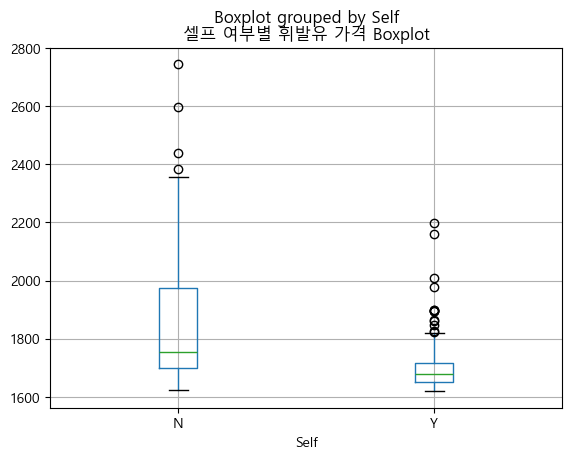

In [33]:
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rc
rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False
plt.figure(figsize=(10, 8))
stations.boxplot(column="Gas Price", by="Self")
plt.title("셀프 여부별 휘발유 가격 Boxplot")
plt.show()

### 경유 가격 셒프 여부별 boxplot

<Figure size 1000x800 with 0 Axes>

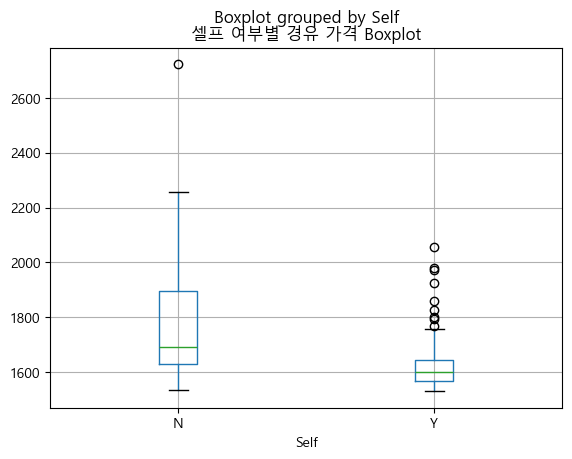

In [34]:
plt.figure(figsize=(10, 8))
stations.boxplot(column="Diesel Price", by="Self")
plt.title("셀프 여부별 경유 가격 Boxplot")
plt.show()

### 구별 휘발유 및 경유 가격의 평균 하위 5위 및 상위 10위 Bar Chart

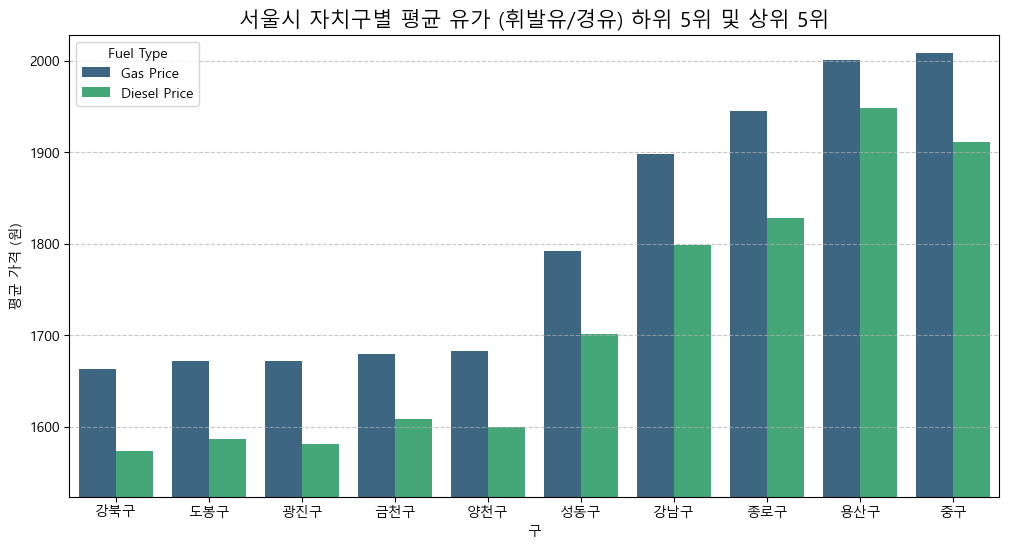

In [47]:
# 휘발유 기준 내림차순 후 상위 5위 및 하위 5위 병합해서 시각화
import seaborn as sns
gu_avg_top_5 = stations.groupby('District')[['Gas Price', 'Diesel Price']].mean().sort_values(by='Gas Price', ascending=True).head(5)
gu_avg_bottom_5 = stations.groupby('District')[['Gas Price', 'Diesel Price']].mean().sort_values(by='Gas Price', ascending=True).tail(5)
gu_avg = pd.concat([gu_avg_top_5, gu_avg_bottom_5]).reset_index(drop=False)
plt.figure(figsize=(12, 6))
gu_avg_melted = gu_avg.reset_index().melt(id_vars='District', var_name='Fuel Type', value_name='Average Price')
gu_avg_melted = gu_avg_melted[gu_avg_melted['Fuel Type'] != 'index']
sns.barplot(data=gu_avg_melted, x='District', y='Average Price', hue='Fuel Type', palette='viridis')
plt.title('서울시 자치구별 평균 유가 (휘발유/경유) 하위 5위 및 상위 5위', fontsize=15)
plt.xlabel('구')
plt.ylabel('평균 가격 (원)')
plt.ylim(gu_avg_melted['Average Price'].min() - 50, gu_avg_melted['Average Price'].max() + 20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 구별 셀프 여부별 휘발유 및 경유 FacetGrid Scatter Plot

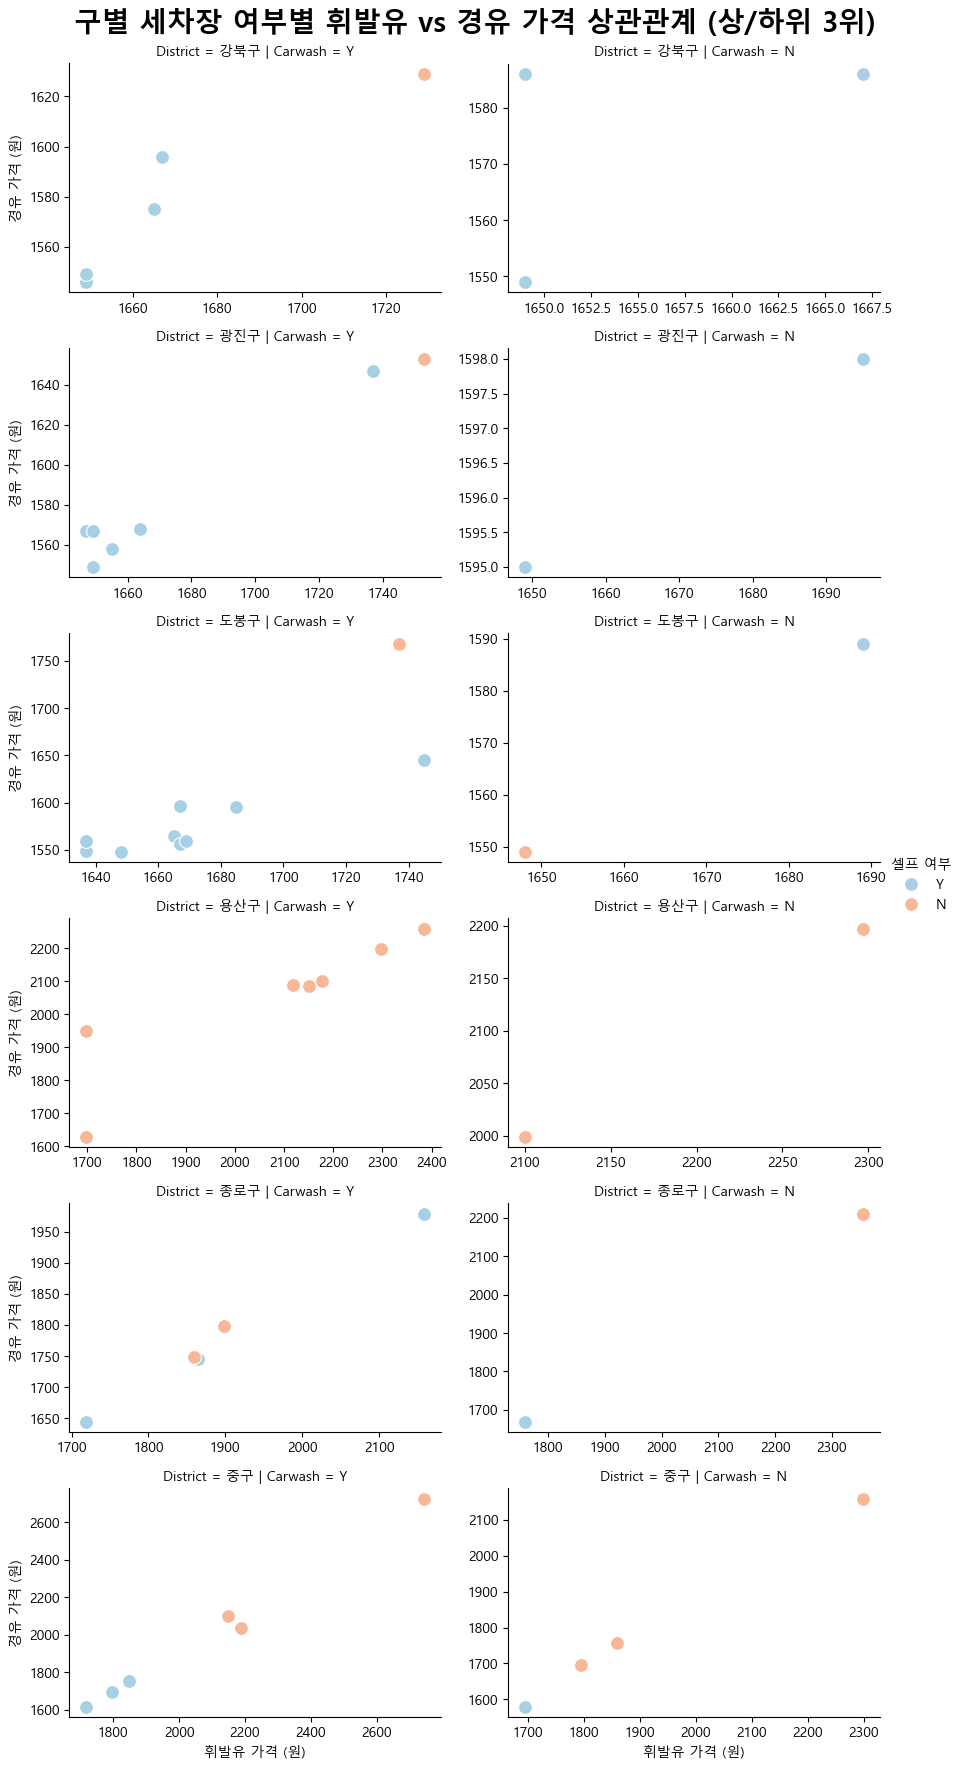

In [75]:
selected_gus = ['강북구', '도봉구', '광진구', '종로구', '용산구', '중구']
df_sample = stations[stations['District'].isin(selected_gus)].copy()
g = sns.FacetGrid(df_sample, row="District", col="Carwash", hue="Self", 
                  hue_order=["Y", "N"], palette='RdBu_r', height=3, 
                  aspect=1.5, sharex=False, sharey=False)
g.map(sns.scatterplot, "Gas Price", "Diesel Price", s=100)
g.add_legend(title="셀프 여부")
plt.subplots_adjust(top=0.95)
plt.suptitle('구별 세차장 여부별 휘발유 vs 경유 가격 상관관계 (상/하위 3위)', 
             fontsize=20, fontweight='bold')
g.set_axis_labels("휘발유 가격 (원)", "경유 가격 (원)")
plt.show()

### Boxplot와 Folium 지도시각화를 통해서 구별 차이 있는지 확인 - 휘발유 가격

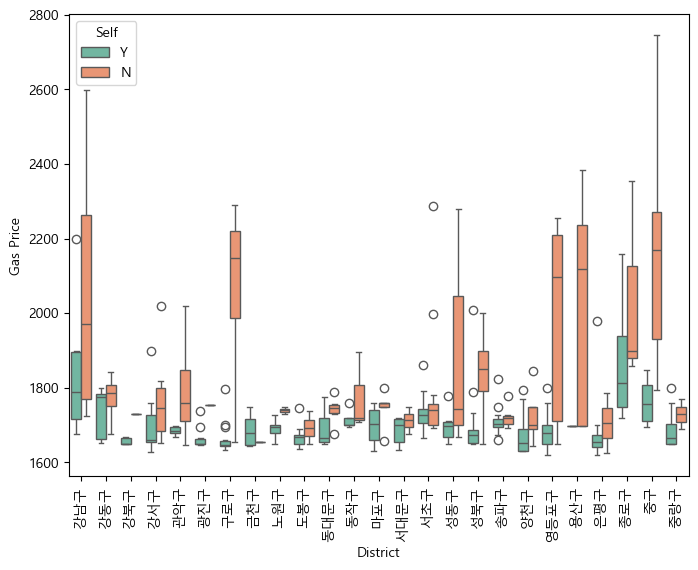

In [55]:
import seaborn as sns
from matplotlib import font_manager, rc
rc("font", family="Malgun Gothic")
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 6))
sns.boxplot(x="District", y = "Gas Price", data=stations, hue="Self", palette="Set2")
plt.xticks(rotation=90)
plt.show()

#### pivot_table 이용해서 구별 셀프 여부별 휘발유 가격 평균의 차이를 구하기

In [56]:
district_gas_price_pivot = stations.pivot_table(values="Gas Price", columns="Self", index="District", aggfunc="mean")
district_gas_price_pivot["Self Cost Advantage"] = district_gas_price_pivot["N"] - district_gas_price_pivot["Y"]
district_gas_price_pivot.sort_values(by="Self Cost Advantage").head()

Self,N,Y,Self Cost Advantage
District,,,
금천구,1655.0,1683.000000,-28.000000
송파구,1722.0,1708.450000,13.550000
은평구,1704.5,1682.454545,22.045455
도봉구,1692.5,1668.666667,23.833333
서대문구,1712.5,1683.916667,28.583333


In [57]:
district_gas_price_pivot.sort_values(by="Self Cost Advantage").tail()

Self,N,Y,Self Cost Advantage
District,,,
강남구,2047.100000,1811.588235,235.511765
영등포구,1977.714286,1681.105263,296.609023
용산구,2028.909091,1698.000000,330.909091
구로구,2060.000000,1662.571429,397.428571
중구,2172.166667,1763.500000,408.666667


#### 그 평균의 차이를 Folium Choropleth을 이용해서 지도 시각화하기

In [115]:
import json
import folium
import copy

geo_path = "./data/skorea_municipalities_geo_simple.json"
geo_str = json.load(open(geo_path, encoding="utf-8"))
temp_geo = copy.deepcopy(geo_str)
# 셀프 주유소의 구별 가격 경쟁력을 temp GeoJSON에 추가하기 (ToolTip용)
for feature in temp_geo['features']:
    district_id = feature['id']
    if district_id in district_gas_price_pivot.index:
        price_val = district_gas_price_pivot.loc[district_id, "Self Cost Advantage"]
        feature['properties']['price_info'] = f"{price_val:,.0f} ₩"
    else:
        feature['properties']['price_info'] = "No Data"

my_map = folium.Map(
    location=[37.5502, 126.982], 
    zoom_start=10.5, 
    tiles="Esri.WorldTopoMap"
)

my_choropleth = folium.Choropleth(
    geo_data=temp_geo,
    data=district_gas_price_pivot["Self Cost Advantage"], 
    columns=[district_gas_price_pivot.index, district_gas_price_pivot["Self Cost Advantage"]], 
    key_on="feature.id", 
    fill_opacity=0.7, 
    line_opacity=0.2, 
    legend_name="구별 셀프 vs 셀프 아닌 평균 휘발유 가격 차이 (마이너스 = 셀프가 비쌈)"
)
my_choropleth.add_to(my_map)

folium.features.GeoJsonTooltip(
        fields=["name", "price_info"],
        aliases=["구:", "셀프 vs vs 셀프 아닌 평균 휘발유 가격 차이:"],
        localize=True,
        sticky=False,
        labels=True,
        max_width=800
    ).add_to(my_choropleth.geojson)

my_map.save("./maps/gas_prices_seoul_map.html")

### Boxplot와 Folium 지도시각화를 통해서 구별 차이 있는지 확인 - 경유 가격

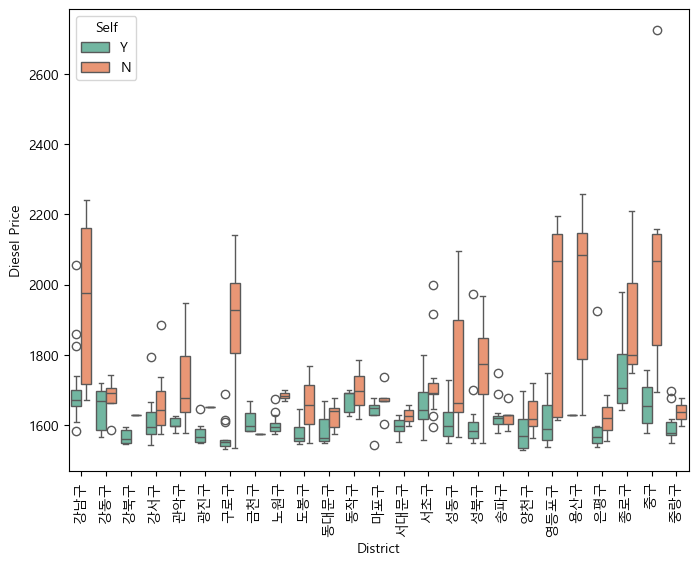

In [104]:
import seaborn as sns
from matplotlib import font_manager, rc
rc("font", family="Malgun Gothic")
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 6))
sns.boxplot(x="District", y = "Diesel Price", data=stations, hue="Self", palette="Set2")
plt.xticks(rotation=90)
plt.show()

#### pivot_table 이용해서 구별 셀프 여부별 경유 가격 평균의 차이를 구하기

In [105]:
district_diesel_price_pivot = stations.pivot_table(values="Diesel Price", columns="Self", index="District", aggfunc="mean")
district_diesel_price_pivot["Self Cost Advantage"] = district_diesel_price_pivot["N"] - district_diesel_price_pivot["Y"]
district_diesel_price_pivot.sort_values(by="Self Cost Advantage").head()

Self,N,Y,Self Cost Advantage
District,,,
금천구,1575.000000,1612.000000,-37.000000
송파구,1623.833333,1623.150000,0.683333
은평구,1619.500000,1601.090909,18.409091
강동구,1678.000000,1648.375000,29.625000
동작구,1700.000000,1669.000000,31.000000


In [106]:
district_diesel_price_pivot.sort_values(by="Self Cost Advantage").tail()

Self,N,Y,Self Cost Advantage
District,,,
강남구,1949.800000,1709.823529,239.976471
영등포구,1916.285714,1606.368421,309.917293
구로구,1882.500000,1565.285714,317.214286
용산구,1977.727273,1628.000000,349.727273
중구,2078.666667,1661.500000,417.166667


#### 그 평균의 차이를 Folium Choropleth을 이용해서 지도 시각화하기

In [117]:
import json
import folium
import copy

geo_path = "./data/skorea_municipalities_geo_simple.json"
geo_str = json.load(open(geo_path, encoding="utf-8"))
temp_geo_diesel = copy.deepcopy(geo_str)
# 셀프 주유소의 구별 가격 경쟁력을 temp GeoJSON에 추가하기 (ToolTip용)
for feature in temp_geo_diesel['features']:
    district_id = feature['id']
    if district_id in district_diesel_price_pivot.index:
        price_val = district_diesel_price_pivot.loc[district_id, "Self Cost Advantage"]
        feature['properties']['price_info'] = f"{price_val:,.0f} ₩"
    else:
        feature['properties']['price_info'] = "No Data"

my_map = folium.Map(
    location=[37.5502, 126.982], 
    zoom_start=10.5, 
    tiles="Esri.WorldTopoMap"
)

my_choropleth = folium.Choropleth(
    geo_data=temp_geo_diesel,
    data=district_diesel_price_pivot["Self Cost Advantage"], 
    columns=[district_diesel_price_pivot.index, district_diesel_price_pivot["Self Cost Advantage"]], 
    key_on="feature.id", 
    fill_opacity=0.7, 
    line_opacity=0.2, 
    legend_name="구별 셀프 vs 셀프 아닌 평균 경유 가격 차이 (마이너스 = 셀프가 비쌈)"
)
my_choropleth.add_to(my_map)

folium.features.GeoJsonTooltip(
        fields=["name", "price_info"],
        aliases=["구:", "셀프 vs vs 셀프 아닌 평균 경유 가격 차이:"],
        localize=True,
        sticky=False,
        labels=True,
        max_width=800
    ).add_to(my_choropleth.geojson)

my_map.save("./maps/diesel_prices_seoul_map.html")

### 단측 독립표본 T-Test이용할 수 있는지 통계적 확인

In [2]:
from scipy import stats
self_gas_price = stations[stations["Self"] == "Y"]["Gas Price"]
statistic, p_value = stats.shapiro(self_gas_price)
print(f"Shapiro-Wilk Test: 검정통계량 값={statistic:.3f}, p-값={p_value:.3f}")
if p_value > 0.05:
    print("셀프 주유소 휘발유 가격은 정규 분포를 따르는 것으로 보입니다 (H0를 기각할 수 없음).")
else:
    print("셀프 주유소 휘발유 가격은 정규 분포를 따르지 않는 것으로 보입니다 (H0 기각함).")

not_self_gas_price = stations[stations["Self"] == "N"]["Gas Price"]
statistic, p_value = stats.shapiro(not_self_gas_price)
print(f"Shapiro-Wilk Test: 검정통계량 값={statistic:.3f}, p-value={p_value:.3f}")
if p_value > 0.05:
    print("셀프 아닌 주유소 휘발유 가격은 정규 분포를 따르는 것으로 보입니다 (H0를 기각할 수 없음).")
else:
    print("셀프 아닌 주유소 휘발유 가격은 정규 분포를 따르지 않는 것으로 보입니다 (H0  기각함).")

self_diesel_price = stations[stations["Self"] == "Y"]["Diesel Price"]
statistic, p_value = stats.shapiro(self_diesel_price)
print(f"Shapiro-Wilk Test: 검정통계량 값={statistic:.3f}, p-value={p_value:.3f}")
if p_value > 0.05:
    print("셀프 주유소 경유 가격은 정규 분포를 따르는 것으로 보입니다 (H0를 기각할 수 없음).")
else:
    print("셀프 주유소 경유 가격은 정규 분포를 따르지 않는 것으로 보입니다 (H0  기각함).")

not_self_diesel_price = stations[stations["Self"] == "N"]["Diesel Price"]
statistic, p_value = stats.shapiro(not_self_diesel_price)
print(f"Shapiro-Wilk Test: 검정통계량 값={statistic:.3f}, p-value={p_value:.3f}")
if p_value > 0.05:
    print("셀프 아닌 주유소 경유 가격은 정규 분포를 따르는 것으로 보입니다 (H0를 기각할 수 없음).")
else:
    print("셀프 아닌 주유소 경유 가격은 정규 분포를 따르지 않는 것으로 보입니다 (H0  기각함).")

Shapiro-Wilk Test: 검정통계량 값=0.742, p-값=0.000
셀프 주유소 휘발유 가격은 정규 분포를 따르지 않는 것으로 보입니다 (H0 기각함).
Shapiro-Wilk Test: 검정통계량 값=0.787, p-value=0.000
셀프 아닌 주유소 휘발유 가격은 정규 분포를 따르지 않는 것으로 보입니다 (H0  기각함).
Shapiro-Wilk Test: 검정통계량 값=0.802, p-value=0.000
셀프 주유소 경유 가격은 정규 분포를 따르지 않는 것으로 보입니다 (H0  기각함).
Shapiro-Wilk Test: 검정통계량 값=0.817, p-value=0.000
셀프 아닌 주유소 경유 가격은 정규 분포를 따르지 않는 것으로 보입니다 (H0  기각함).


In [3]:
from scipy.stats import levene
statistic, p_value = levene(self_gas_price, not_self_gas_price)
print(f"Levene's Test for Equal Variances 검정통계량 값: {statistic:.3f}")
print(f"p-값: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print("H0를 기각할 수 없음: 셀프 여부별 휘발유 가격은 등분산 가정이 위배되었습니다 (p-값 < 0.05).")
else:
    print("H0를 기각함: 셀프 여부별 휘발유 가격은 등분산 가정이 충족되었습니다 (p-값 > 0.05).")

statistic, p_value = levene(self_diesel_price, not_self_diesel_price)
print(f"Levene's Test for Equal Variances 검정통계량 값: {statistic:.3f}")
print(f"p-값: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print("H0를 기각할 수 없음: 셀프 여부별 경유 가격은 등분산 가정이 위배되었습니다 (p-값 < 0.05).")
else:
    print("H0를 기각함: 셀프 여부별 경유 가격은 등분산 가정이 충족되었습니다 (p-값 > 0.05).")

Levene's Test for Equal Variances 검정통계량 값: 70.423
p-값: 0.000
H0를 기각할 수 없음: 셀프 여부별 휘발유 가격은 등분산 가정이 위배되었습니다 (p-값 < 0.05).
Levene's Test for Equal Variances 검정통계량 값: 78.325
p-값: 0.000
H0를 기각할 수 없음: 셀프 여부별 경유 가격은 등분산 가정이 위배되었습니다 (p-값 < 0.05).


#### T-Test의 가정 검정/가정사항 확인:
- **연속 데이터: 충족됨** - 휘발유 및 경유 가격은 둘 다 한국 원화로 측정되며, 원화는 연속적인 척도 (이산 척도 아님)입니다.
- **독립성: 충족됨** - 각 주유소는 독립적으로 위치해 있으며, 셀프 여부 분류도 다른 주유소와는 무관하므로 데이터는 독립적입니다.
- **정규성: 충족됨** - Shapiro-Wilk Test 결과 정규성이 위배되었으나, 본 데이터셋은 **중심극한정리(Central Limit Theorem)**를 적용하기에 충분한 샘플 수를 확보하고 있습니다. 따라서 t-test의 강건성(Robustness)을 신뢰할 수 있다고 판단했습니다.
- **등분산성: 위배됨** - Levene Test 결과 (가설한 바와 같이) 등분산성이 성립하지 않아 Welch's t-test을 수행해야 합니다.
- **무작위 추출: 위배됨** - 샘플이 무작위 추출은 아니지만 모집단 일반화가 아닌 비확률 표집 (수집된 주유소 데이터) 중 두 표본 (셀프 여부별) 간의 평균 차이 비교가 목적이므로 결과를 제대로 설명하기만 하면 t-test 수행해도 됩니다.
#### 단측 독립표본 T-Test 대신 단측 Welch's T-Test을 수행하는 이유: 이분산

#### 휘발유 단측 Welch's T-test 가설검정:
- 귀무가설: 셀프 주유소 휘발유 가격 평균 = 셀프 아닌 주유소 휘발유 가격 평균
- 대립가설: 셀프 주유소 휘발유 가격 평균 < 셀프 아닌 주유소 휘발유 가격 평균 (셀프 주유소의 휘발유 가격이 일반 주유소보다 평균적으로 저렴할 것이라는 가설이 세워졌다.)

In [4]:
from scipy import stats
statistic, p_value = stats.ttest_ind(self_gas_price, not_self_gas_price, equal_var=False, alternative='less')
alpha = 0.05
if p_value < alpha:
    print("귀무가설을 기각함.")
else:
    print("귀무가설을 기각할 수 없음.")

print(f"Welch's T-Test 검정통계량 값: {statistic}")
print(f"단측 p-값: {p_value}")

귀무가설을 기각함.
Welch's T-Test 검정통계량 값: -7.587129400976819
단측 p-값: 2.3215957815444847e-12


#### 경유 단측 Welch's T-test 가설검정:
- 귀무가설: 셀프 주유소 경유 가격 평균 = 셀프 아닌 주유소 경유 가격 평균
- 대립가설: 셀프 주유소 경유 가격 평균 < 셀프 아닌 주유소 경유 가격 평균 (셀프 주유소의 경유 가격이 일반 주유소보다 평균적으로 저렴할 것이라는 가설이 세워졌다.)

In [5]:
from scipy import stats
statistic, p_value = stats.ttest_ind(self_diesel_price, not_self_diesel_price, equal_var=False, alternative='less')
alpha = 0.05
if p_value < alpha:
    print("귀무가설을 기각함.")
else:
    print("귀무가설을 기각할 수 없음.")

print(f"Welch's T-Test 검정통계량 값: {statistic}")
print(f"단측 p-값: {p_value}")

귀무가설을 기각함.
Welch's T-Test 검정통계량 값: -8.122458377681873
단측 p-값: 1.1695329695204435e-13


### 분석 결과:
- 셀프 여부별 휘발유 가격의 평균과 경유 가격의 평균, 그리고 셀프 여부별 휘발유 가격과 경유 가격의 boxplot을 보시면, 셀프인 주유소의 평균 가격은 셀프 아닌 주유의 평균 가격보다 싼 가격인 것으로 보입니다.
- 하지만, 구별 평균 데이터를 보시면, 구별 가격 차이가 다르다. 예를 들면, 많은 구역에서는 셀프 주유소가 저렴하지만 금천구에서는 셀프 주유소는 (휘발유나 경유 상관없이) 셀프 아닌 주유소보다 비싸다. 휘발유 가격은 도봉구, 서초구, 송파구에는 셀프와 셀프 아닌 주유소중 가격 편차 그리고 경유 가격은 동대문구, 서대문구, 송파구에는 셀프와 셀프 아닌 주유소중 가격 편차가 통계적으로 유의미하지 않은 수준(Statistically insignificant)으로 나타나며, 가격 하향 평준화(Price convergence) 경향을 보입니다.
- 또한, 지도 시각화를 보시면, 셀프 주유소는 셀프 아닌 주유소보다 (휘발유나 경유 상관없이) 가장 많이 저렴한 구역은 구로구, 중구, 영등포구, 강남구와 용산구입니다.
- 더 확실한 결과 얻으려고 통계적 단측 독립표본 t-test도 수행해보고 싶었는데 각 표본의 분산이 동일하지 않아서 단측 Welch's t-test를 수행했습니다.
- 보시다시피 그 Welch's t-test의 결과 p-value는 0.05보다 훨씬 작아서 귀무가설을 기각합니다. 그래서 통계적으로는 서울시 셀프 주유소는 (휘발유나 경유 상관없이) 보통 셀프 아닌 주유소보다 저렴하다는 것은 확실합니다. 그래도 그 통계적 결과가 서울시 전체적 데이터로 계산해서 구별 Welch's t-test의 결과 다를 수도 있습니다. (구별 데이터가 너무 적어서 Central Limit Theorem을 적용 목 해서 정규성 가정을 무시하지 못하여, 구별 Welch's t-test 수행할 수 없습니다.)
- 나중에 시간이 되면 구별만 아니라 브랜드나 부가정보 (세차장, 충전소, 경정비, 편의점, 24시간 운영 여부)에 따라 셀프 여부별 주유소 휘발유이나 경유 가격 차이가 있는지 확인하는 것 권유 드립니다.

## 3. 결론 및 비즈니스 영향
- **통계적 의사결정:** Welch's t-test를 통해 서울시 내 셀프 주유소가 통계적으로 유의미하게 저렴함을 입증했습니다. 이는 소비자에게 '셀프 주유'가 실질적인 비용 절감 수단이 됨을 데이터로 증명한 것입니다.
- **지역적 특수성 고려:** 하지만 금천구와 같은 특정 지역에서는 셀프 주유소가 오히려 더 비싼 '가격 역전 현상'이나, 일부 자치구의 '가격 하향 평준화(Price Convergence)' 경향이 확인되었습니다.
- **비즈니스 인사이트:** 운송업체나 일반 운전자는 단순히 '셀프 여부'만 따지기보다, 자치구별 가격 편차를 우선적으로 고려해야 합니다. 특히 고가 지역(중구, 강남구 등)에서는 셀프와 일반 주유소의 가격 격차가 크므로 셀프 이용의 경제적 유인이 극대화되지만, 저가 지역이나 특정 예외 지역에서는 인근 일반 주유소를 이용하는 것이 시간 대비 효율적일 수 있습니다.